In [83]:
import chainladder as cl


In [84]:
tri_1997 = cl.load_sample("clrd")
tri_1997 = tri_1997.groupby("LOB").sum().loc["medmal"]["CumPaidLoss"]

In [ ]:

tri_1996 = tri_1997[tri_1997.valuation < "1998"] #tutaj zmieniam na rok żeby rozjazd zobaczyć
model_1996 = cl.Chainladder().fit(cl.TailCurve().fit_transform(tri_1996))

ave = model_1996.full_triangle_.dev_to_val()
ave = ave[ave.valuation == tri_1997.valuation_date].rename("columns", "Expected")

#sprawdzam odsłanianie szkód

In [86]:

ave["Actual"] = tri_1997.latest_diagonal[tri_1997.origin < "1998"] #tutaj też zmieniam żeby rozjazd zobaczyć
df = ave.to_frame().T.iloc[::-1]

Text(0, 0.5, 'Origin')

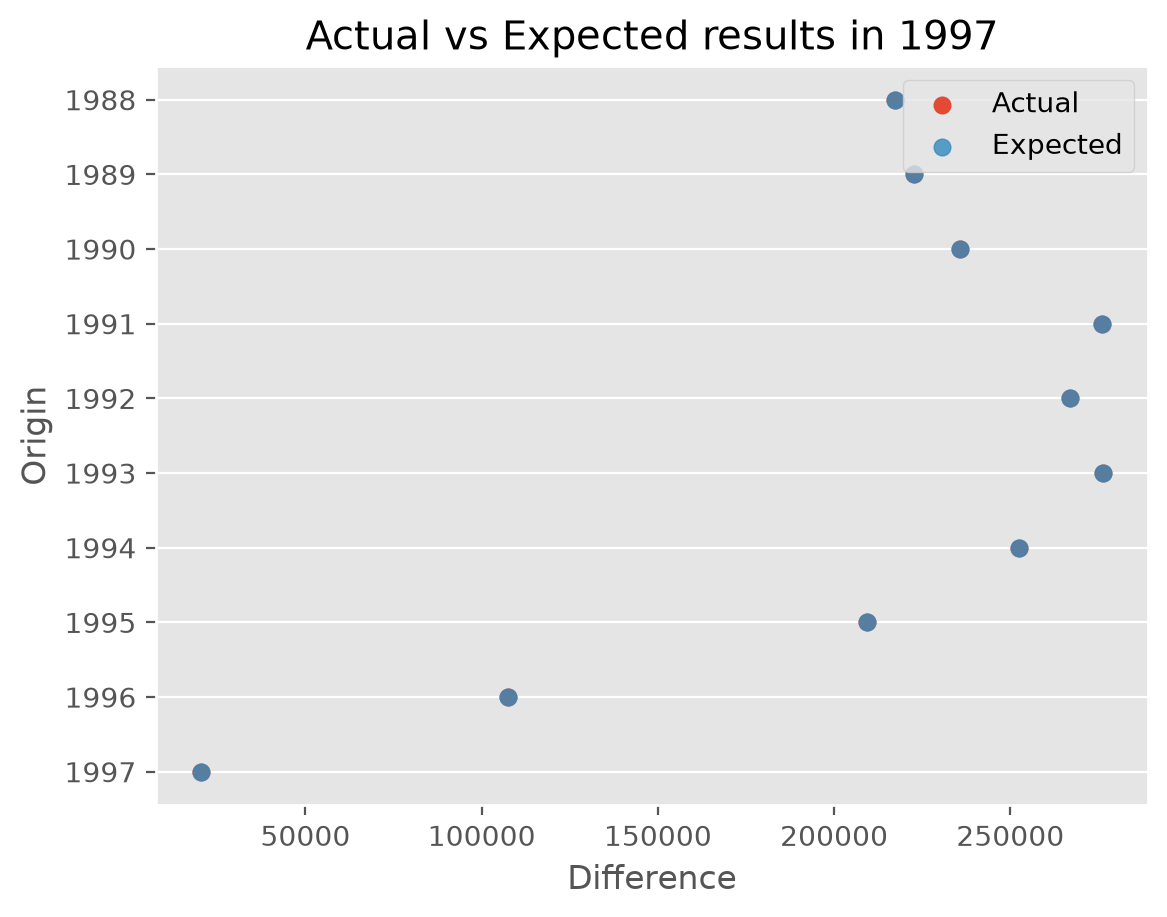

In [87]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")
%config InlineBackend.figure_format = 'retina'

# Plotting
fig, ax = plt.subplots()
ax.grid(axis="x")
plt.hlines(
    y=df.index.astype(str),
    xmin=df["Actual"],
    xmax=df["Expected"],
    color="grey",
    alpha=0.4,
)
plt.scatter(df["Actual"], df.index.astype(str), alpha=1, label="Actual")
plt.scatter(df["Expected"], df.index.astype(str), alpha=0.8, label="Expected")
plt.legend()
plt.title("Actual vs Expected results in 1997")
plt.xlabel("Difference")
plt.ylabel("Origin")